# Home Credit Default Risk — Phase 4: Feature Engineering

**Objective:** Build the master training table by aggregating all secondary files and creating domain-driven features.

This is the **highest-impact phase** in this competition. Top Kaggle solutions get 90%+ of their score from feature engineering, not from model tuning.

## What we build here

| Block | Source | Features created |
|---|---|---|
| A | application_train/test (clean) | Ratio features, EXT_SOURCE combinations, age/employment features |
| B | bureau + bureau_balance | Credit history aggregations, overdue counts, active loan stats |
| C | previous_application | Past HC loan aggregations, approval ratios, contract type stats |
| D | installments_payments | Payment behaviour — ratio paid, days past due, underpayment |
| E | POS_CASH_balance | Active loan counts, remaining installments, contract status |
| F | credit_card_balance | Utilization ratio, drawing behaviour, payment regularity |

**Final master table:** All blocks merged on `SK_ID_CURR` → single wide table for Phase 5 (PCA) and Phase 6 (Modeling).


In [4]:
import os, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

plt.rcParams.update({
    'figure.facecolor':'#FAFAFA','axes.facecolor':'#FAFAFA',
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.labelsize':11,'xtick.labelsize':9,'ytick.labelsize':9,
})
C0, C1 = '#534AB7', '#D85A30'

DATA_DIR   = '../data'     # raw Kaggle CSVs — update if different location
CLEAN_DIR  = './preprocessed/'   # Phase 3 output
OUTPUT_DIR = './features/'       # Phase 4 output
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Load all cleaned files ────────────────────────────────────────────────────
train    = pd.read_csv(os.path.join(CLEAN_DIR, 'train_clean.csv'))
test     = pd.read_csv(os.path.join(CLEAN_DIR, 'test_clean.csv'))
bureau   = pd.read_csv(os.path.join(CLEAN_DIR, 'bureau_clean.csv'))
bbal     = pd.read_csv(os.path.join(CLEAN_DIR, 'bureau_balance_clean.csv'))
prev_app = pd.read_csv(os.path.join(CLEAN_DIR, 'previous_application_clean.csv'))
pos      = pd.read_csv(os.path.join(CLEAN_DIR, 'POS_CASH_balance_clean.csv'))
install  = pd.read_csv(os.path.join(CLEAN_DIR, 'installments_payments_clean.csv'))
cc       = pd.read_csv(os.path.join(CLEAN_DIR, 'credit_card_balance_clean.csv'))

print('Loaded cleaned files:')
for name, df in [('train',train),('test',test),('bureau',bureau),
                  ('bureau_balance',bbal),('previous_application',prev_app),
                  ('POS_CASH_balance',pos),('installments_payments',install),
                  ('credit_card_balance',cc)]:
    print(f'  {name:<30} {df.shape}')

# Shared constants
TARGET    = train['TARGET'].copy()
TRAIN_IDS = train['SK_ID_CURR'].values
TEST_IDS  = test['SK_ID_CURR'].values
print(f'\nTrain applicants: {len(TRAIN_IDS):,} | Test applicants: {len(TEST_IDS):,}')
# ── Load raw columns needed for overdue + approval features ──────────────────
# Phase 3 label-encoded STATUS and NAME_CONTRACT_STATUS — we need original strings
# Load ONLY the specific columns needed (memory efficient)
RAW_DIR = DATA_DIR if 'DATA_DIR' in dir() else CLEAN_DIR.replace('preprocessed/', '')

# Try to load raw bureau_balance STATUS
bbal_status_path = os.path.join(DATA_DIR, 'bureau_balance.csv')
if os.path.exists(bbal_status_path):
    bbal_raw_status = pd.read_csv(bbal_status_path, usecols=['SK_ID_BUREAU','STATUS'])
    print(f'  Raw bureau_balance STATUS loaded: {bbal_raw_status.shape}')
else:
    bbal_raw_status = None
    print('  bureau_balance.csv not found in ./ — overdue counts will be skipped')

# Try to load raw previous_application NAME_CONTRACT_STATUS
prev_status_path = os.path.join(DATA_DIR, 'previous_application.csv')
if os.path.exists(prev_status_path):
    prev_raw_status = pd.read_csv(prev_status_path, usecols=['SK_ID_CURR','NAME_CONTRACT_STATUS'])
    print(f'  Raw previous_application STATUS loaded: {prev_raw_status.shape}')
else:
    prev_raw_status = None
    print('  previous_application.csv not found in ./ — approval rates will be skipped')


Loaded cleaned files:
  train                          (307511, 116)
  test                           (48744, 115)
  bureau                         (1716428, 15)
  bureau_balance                 (27299925, 3)
  previous_application           (1670214, 34)
  POS_CASH_balance               (10001358, 8)
  installments_payments          (13605401, 8)
  credit_card_balance            (3840312, 23)

Train applicants: 307,511 | Test applicants: 48,744
  Raw bureau_balance STATUS loaded: (27299925, 2)
  Raw previous_application STATUS loaded: (1670214, 2)


## 1. Aggregation Helper Function

A reusable function that:
- Groups a dataframe by `SK_ID_CURR`
- Computes mean, max, min, sum, std, count for all numeric columns
- Prefixes every output column with a file-specific tag
- Returns a flat dataframe indexed by `SK_ID_CURR`

This pattern is how MNC data science teams handle many-to-one joins cleanly.

In [5]:
def aggregate_by_id(df, group_col, prefix, agg_funcs=None):
    """
    Aggregate all numeric columns in df by group_col.
    Returns a dataframe prefixed with `prefix_` for easy identification.

    Parameters
    ----------
    df         : DataFrame to aggregate
    group_col  : Column to group by (e.g. 'SK_ID_CURR')
    prefix     : String prefix for output column names
    agg_funcs  : List of aggregation functions (default: mean, max, min, sum, std, count)
    """
    if agg_funcs is None:
        agg_funcs = ['mean', 'max', 'min', 'sum', 'std', 'count']

    ID_KEYS = ['SK_ID_CURR', 'SK_ID_BUREAU', 'SK_ID_PREV']
    num_cols = [c for c in df.select_dtypes(include='number').columns
                if c not in ID_KEYS]

    agg_dict = {col: agg_funcs for col in num_cols}
    result   = df.groupby(group_col).agg(agg_dict)

    # Flatten multi-level column index
    result.columns = [f'{prefix}_{col}_{func}' for col, func in result.columns]
    result         = result.reset_index()

    # Add total row count per applicant as a feature
    count_col      = f'{prefix}_ROW_COUNT'
    row_counts     = df.groupby(group_col).size().reset_index(name=count_col)
    result         = result.merge(row_counts, on=group_col, how='left')

    print(f'  [{prefix}] Shape: {result.shape} | New features: {result.shape[1]-1}')
    return result


print('Aggregation helper loaded.')

Aggregation helper loaded.


## 2. Block A — Application-Level Feature Engineering

These are domain-driven features created directly from `application_train/test`.
Based on Phase 2 EDA findings:
- **EXT_SOURCE** features are the top 3 predictors → combine them
- **DAYS_BIRTH** → age in years (younger = higher default risk)
- **DAYS_EMPLOYED** → employment ratio relative to age
- **AMT_CREDIT / AMT_INCOME** → debt burden
- **AMT_ANNUITY / AMT_INCOME** → repayment burden

> All features created on train are mirrored exactly on test.

In [6]:
def create_application_features(df):
    """
    Create domain-driven features from application_train/test.
    Input: cleaned application dataframe.
    Returns: same dataframe with new columns appended.
    """
    df = df.copy()
    eps = 1e-5   # avoid division by zero

    # ── Age & Employment ─────────────────────────────────────────────────────
    if 'DAYS_BIRTH' in df.columns:
        df['APP_AGE_YEARS']          = (-df['DAYS_BIRTH'] / 365).round(2)
        df['APP_AGE_YEARS_SQUARED']  = df['APP_AGE_YEARS'] ** 2   # captures non-linear age effect

    if 'DAYS_EMPLOYED' in df.columns and 'DAYS_BIRTH' in df.columns:
        df['APP_EMPLOYMENT_YEARS']   = (-df['DAYS_EMPLOYED'] / 365).round(2)
        # Ratio of time employed vs age — high ratio = stable employment
        df['APP_EMPLOYED_TO_AGE_RATIO'] = df['DAYS_EMPLOYED'] / (df['DAYS_BIRTH'] + eps)

    if 'DAYS_REGISTRATION' in df.columns and 'DAYS_BIRTH' in df.columns:
        df['APP_REGISTRATION_TO_AGE_RATIO'] = df['DAYS_REGISTRATION'] / (df['DAYS_BIRTH'] + eps)

    if 'DAYS_ID_PUBLISH' in df.columns and 'DAYS_BIRTH' in df.columns:
        df['APP_ID_PUBLISH_TO_AGE_RATIO'] = df['DAYS_ID_PUBLISH'] / (df['DAYS_BIRTH'] + eps)

    # ── Credit & Income Ratios ────────────────────────────────────────────────
    if 'AMT_CREDIT' in df.columns and 'AMT_INCOME_TOTAL' in df.columns:
        df['APP_CREDIT_INCOME_RATIO']  = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + eps)
        df['APP_INCOME_CREDIT_RATIO']  = df['AMT_INCOME_TOTAL'] / (df['AMT_CREDIT'] + eps)

    if 'AMT_ANNUITY' in df.columns and 'AMT_INCOME_TOTAL' in df.columns:
        df['APP_ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + eps)

    if 'AMT_CREDIT' in df.columns and 'AMT_ANNUITY' in df.columns:
        # Loan term in months (how long to repay)
        df['APP_CREDIT_TERM']          = df['AMT_CREDIT'] / (df['AMT_ANNUITY'] + eps)

    if 'AMT_GOODS_PRICE' in df.columns and 'AMT_CREDIT' in df.columns:
        # How much extra credit vs actual goods value (loan-to-value)
        df['APP_CREDIT_TO_GOODS_RATIO'] = df['AMT_CREDIT'] / (df['AMT_GOODS_PRICE'] + eps)
        df['APP_GOODS_CREDIT_DIFF']     = df['AMT_GOODS_PRICE'] - df['AMT_CREDIT']

    if 'AMT_INCOME_TOTAL' in df.columns and 'CNT_FAM_MEMBERS' in df.columns:
        df['APP_INCOME_PER_PERSON']    = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + eps)

    if 'AMT_ANNUITY' in df.columns and 'AMT_GOODS_PRICE' in df.columns:
        df['APP_ANNUITY_TO_GOODS_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_GOODS_PRICE'] + eps)

    # ── EXT_SOURCE Combinations (top predictors from Phase 2 EDA) ───────────
    ext_cols = [c for c in ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3'] if c in df.columns]
    if len(ext_cols) >= 2:
        df['APP_EXT_SOURCE_MEAN']    = df[ext_cols].mean(axis=1)
        df['APP_EXT_SOURCE_STD']     = df[ext_cols].std(axis=1)
        df['APP_EXT_SOURCE_MIN']     = df[ext_cols].min(axis=1)
        df['APP_EXT_SOURCE_MAX']     = df[ext_cols].max(axis=1)
        df['APP_EXT_SOURCE_RANGE']   = df['APP_EXT_SOURCE_MAX'] - df['APP_EXT_SOURCE_MIN']
    if len(ext_cols) == 3:
        # Product amplifies the combined credit score signal
        df['APP_EXT_SOURCE_PRODUCT'] = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']
        # Weighted combination (EXT_SOURCE_2 strongest per competition history)
        df['APP_EXT_WEIGHTED']       = (0.25*df['EXT_SOURCE_1'] +
                                        0.50*df['EXT_SOURCE_2'] +
                                        0.25*df['EXT_SOURCE_3'])

    # EXT_SOURCE × credit ratio interactions
    if 'EXT_SOURCE_2' in df.columns and 'APP_CREDIT_INCOME_RATIO' in df.columns:
        df['APP_EXT2_x_CREDIT_INCOME'] = df['EXT_SOURCE_2'] * df['APP_CREDIT_INCOME_RATIO']
    if 'EXT_SOURCE_3' in df.columns and 'APP_ANNUITY_INCOME_RATIO' in df.columns:
        df['APP_EXT3_x_ANNUITY_INCOME'] = df['EXT_SOURCE_3'] * df['APP_ANNUITY_INCOME_RATIO']

    # ── Document flags ────────────────────────────────────────────────────────
    doc_cols = [c for c in df.columns if c.startswith('FLAG_DOCUMENT_')]
    if doc_cols:
        df['APP_DOCUMENTS_PROVIDED_COUNT'] = df[doc_cols].sum(axis=1)

    # ── Social enquiries ─────────────────────────────────────────────────────
    req_cols = [c for c in df.columns if 'AMT_REQ_CREDIT_BUREAU' in c]
    if req_cols:
        df['APP_TOTAL_CREDIT_ENQUIRIES'] = df[req_cols].sum(axis=1)

    # ── Population region relative score ─────────────────────────────────────
    if 'REGION_POPULATION_RELATIVE' in df.columns and 'AMT_INCOME_TOTAL' in df.columns:
        df['APP_INCOME_TO_REGION_RATIO'] = df['AMT_INCOME_TOTAL'] / (df['REGION_POPULATION_RELATIVE'] + eps)

    return df


# Apply to both train and test
train = create_application_features(train)
test  = create_application_features(test)

new_app_feats = [c for c in train.columns if c.startswith('APP_')]
print(f'Application-level features created: {len(new_app_feats)}')
for f in new_app_feats:
    print(f'  {f}')

Application-level features created: 26
  APP_AGE_YEARS
  APP_AGE_YEARS_SQUARED
  APP_EMPLOYMENT_YEARS
  APP_EMPLOYED_TO_AGE_RATIO
  APP_REGISTRATION_TO_AGE_RATIO
  APP_ID_PUBLISH_TO_AGE_RATIO
  APP_CREDIT_INCOME_RATIO
  APP_INCOME_CREDIT_RATIO
  APP_ANNUITY_INCOME_RATIO
  APP_CREDIT_TERM
  APP_CREDIT_TO_GOODS_RATIO
  APP_GOODS_CREDIT_DIFF
  APP_INCOME_PER_PERSON
  APP_ANNUITY_TO_GOODS_RATIO
  APP_EXT_SOURCE_MEAN
  APP_EXT_SOURCE_STD
  APP_EXT_SOURCE_MIN
  APP_EXT_SOURCE_MAX
  APP_EXT_SOURCE_RANGE
  APP_EXT_SOURCE_PRODUCT
  APP_EXT_WEIGHTED
  APP_EXT2_x_CREDIT_INCOME
  APP_EXT3_x_ANNUITY_INCOME
  APP_DOCUMENTS_PROVIDED_COUNT
  APP_TOTAL_CREDIT_ENQUIRIES
  APP_INCOME_TO_REGION_RATIO


### 2a. Validate EXT_SOURCE Feature Strength

Confirm that our engineered EXT_SOURCE combinations have stronger TARGET correlation than raw features.

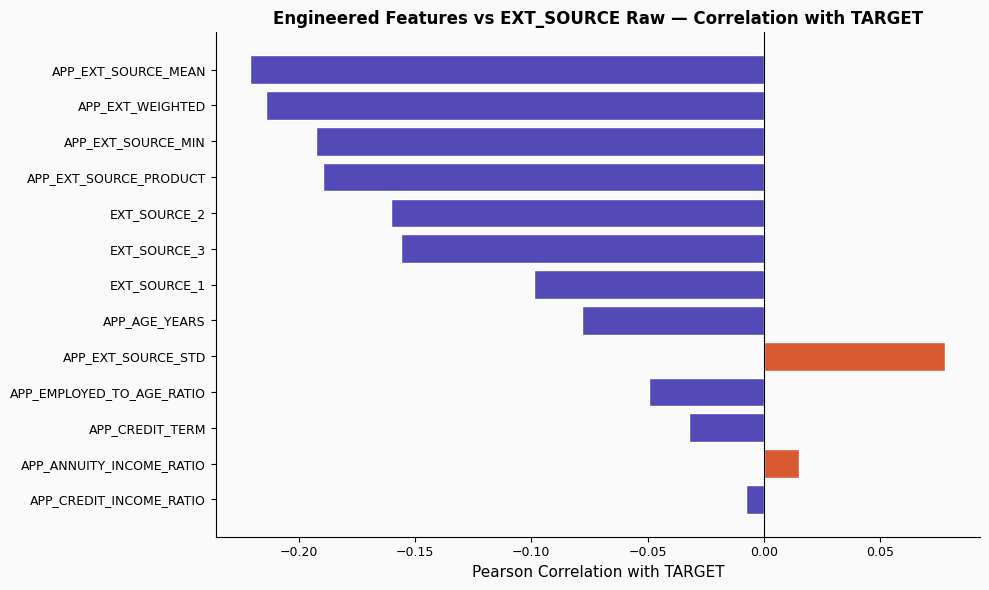


Correlation values:
APP_EXT_SOURCE_MEAN         -0.2208
APP_EXT_WEIGHTED            -0.2141
APP_EXT_SOURCE_MIN          -0.1928
APP_EXT_SOURCE_PRODUCT      -0.1896
EXT_SOURCE_2                -0.1603
EXT_SOURCE_3                -0.1559
EXT_SOURCE_1                -0.0989
APP_AGE_YEARS               -0.0782
APP_EXT_SOURCE_STD           0.0780
APP_EMPLOYED_TO_AGE_RATIO   -0.0496
APP_CREDIT_TERM             -0.0323
APP_ANNUITY_INCOME_RATIO     0.0151
APP_CREDIT_INCOME_RATIO     -0.0076


In [7]:
ext_check_cols = [c for c in [
    'EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3',
    'APP_EXT_SOURCE_MEAN','APP_EXT_SOURCE_PRODUCT',
    'APP_EXT_WEIGHTED','APP_EXT_SOURCE_MIN','APP_EXT_SOURCE_STD',
    'APP_CREDIT_INCOME_RATIO','APP_ANNUITY_INCOME_RATIO',
    'APP_CREDIT_TERM','APP_AGE_YEARS','APP_EMPLOYED_TO_AGE_RATIO',
] if c in train.columns]

corr_check = train[ext_check_cols + ['TARGET']].corr()['TARGET'].drop('TARGET').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [C1 if v > 0 else C0 for v in corr_check.values]
ax.barh(corr_check.index, corr_check.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Engineered Features vs EXT_SOURCE Raw — Correlation with TARGET',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Pearson Correlation with TARGET')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('phase4_app_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nCorrelation values:')
print(corr_check.to_string())

## 3. Block B — Bureau Feature Engineering

`bureau.csv` contains a client's **credit history from other financial institutions** (via Credit Bureau).

**2-level rollup (identified in Phase 1):**
1. Aggregate `bureau_balance` → `SK_ID_BUREAU` level
2. Merge into `bureau` on `SK_ID_BUREAU`
3. Aggregate `bureau` (enriched) → `SK_ID_CURR` level

**Domain features to engineer:**
- Count of active vs closed credits
- Total overdue amount
- Longest overdue period
- Average credit utilization across all bureau credits
- Overdue months from bureau_balance STATUS column

In [9]:
# ── Step 1: Aggregate bureau_balance → SK_ID_BUREAU level ──────────────────
print('Step 1: Aggregate bureau_balance → SK_ID_BUREAU level')

bbal_work = bbal.copy()

bbal_agg = aggregate_by_id(bbal_work, 'SK_ID_BUREAU', 'BBAL',
                            agg_funcs=['mean','max','sum','count'])
print(f'  bureau_balance aggregated shape: {bbal_agg.shape}')

# ── Step 2: Merge bureau_balance aggregations into bureau ────────────────────
print('\nStep 2: Merge bureau_balance aggregations into bureau')
bureau_enr = bureau.merge(bbal_agg, on='SK_ID_BUREAU', how='left')
print(f'  bureau enriched shape: {bureau_enr.shape}')

# ── Step 3: Domain features inside bureau ────────────────────────────────────
print('\nStep 3: Create domain features inside bureau')
eps = 1e-5

# bureau_balance STATUS overdue counts — uses raw STATUS strings loaded in Cell 2
# STATUS: 0=no debt, 1-5=overdue months, C=closed, X=unknown
if bbal_raw_status is not None:
    bbal_raw_status['IS_OVERDUE'] = bbal_raw_status['STATUS'].isin(
        ['1','2','3','4','5']
    ).astype(int)
    overdue_counts = bbal_raw_status.groupby('SK_ID_BUREAU').agg(
        BBAL_OVERDUE_MONTHS = ('IS_OVERDUE', 'sum'),
        BBAL_OVERDUE_RATE   = ('IS_OVERDUE', 'mean'),
        BBAL_TOTAL_MONTHS   = ('IS_OVERDUE', 'count'),
    ).reset_index()
    bureau_enr = bureau_enr.merge(overdue_counts, on='SK_ID_BUREAU', how='left')
    print(f'  Added overdue month counts: {overdue_counts.shape}')
    del bbal_raw_status
    gc.collect()
else:
    print('  Skipping overdue counts — raw bureau_balance.csv not available')

# Debt / credit ratios
if 'AMT_CREDIT_SUM' in bureau_enr.columns and 'AMT_CREDIT_SUM_DEBT' in bureau_enr.columns:
    bureau_enr['BUR_DEBT_CREDIT_RATIO'] = (
        bureau_enr['AMT_CREDIT_SUM_DEBT'] / (bureau_enr['AMT_CREDIT_SUM'] + eps)
    )

if 'AMT_CREDIT_SUM_LIMIT' in bureau_enr.columns and 'AMT_CREDIT_SUM' in bureau_enr.columns:
    bureau_enr['BUR_LIMIT_CREDIT_RATIO'] = (
        bureau_enr['AMT_CREDIT_SUM_LIMIT'] / (bureau_enr['AMT_CREDIT_SUM'] + eps)
    )

if 'AMT_CREDIT_SUM_OVERDUE' in bureau_enr.columns and 'AMT_CREDIT_SUM' in bureau_enr.columns:
    bureau_enr['BUR_OVERDUE_CREDIT_RATIO'] = (
        bureau_enr['AMT_CREDIT_SUM_OVERDUE'] / (bureau_enr['AMT_CREDIT_SUM'] + eps)
    )

if 'DAYS_CREDIT' in bureau_enr.columns and 'DAYS_CREDIT_ENDDATE' in bureau_enr.columns:
    bureau_enr['BUR_CREDIT_DURATION'] = (
        bureau_enr['DAYS_CREDIT_ENDDATE'] - bureau_enr['DAYS_CREDIT']
    )

# ── Step 4: Aggregate enriched bureau → SK_ID_CURR level ─────────────────────
print('\nStep 4: Aggregate enriched bureau → SK_ID_CURR')
bureau_feat = aggregate_by_id(bureau_enr, 'SK_ID_CURR', 'BUR')
print(f'  bureau features shape: {bureau_feat.shape}')
gc.collect()


Step 1: Aggregate bureau_balance → SK_ID_BUREAU level
  [BBAL] Shape: (817395, 10) | New features: 9
  bureau_balance aggregated shape: (817395, 10)

Step 2: Merge bureau_balance aggregations into bureau
  bureau enriched shape: (1716428, 24)

Step 3: Create domain features inside bureau
  Added overdue month counts: (817395, 4)

Step 4: Aggregate enriched bureau → SK_ID_CURR
  [BUR] Shape: (305810, 176) | New features: 175
  bureau features shape: (305810, 176)


0

## 4. Block C — Previous Application Feature Engineering

`previous_application.csv` contains all **past Home Credit loan applications** for each client.

**Domain features to engineer:**
- Approval ratio (approved / total applications)
- Average down payment ratio
- Ratio of credit received vs credit applied for
- Count of active vs refused applications
- Statistics on annuity, credit amounts from past applications

In [10]:
prev_work = prev_app.copy()
eps = 1e-5

# ── Domain features inside previous_application ──────────────────────────────
if 'AMT_CREDIT' in prev_work.columns and 'AMT_APPLICATION' in prev_work.columns:
    prev_work['PREV_CREDIT_TO_APPLICATION_RATIO'] = (
        prev_work['AMT_CREDIT'] / (prev_work['AMT_APPLICATION'] + eps)
    )

if 'AMT_DOWN_PAYMENT' in prev_work.columns and 'AMT_GOODS_PRICE' in prev_work.columns:
    prev_work['PREV_DOWN_PAYMENT_RATIO'] = (
        prev_work['AMT_DOWN_PAYMENT'] / (prev_work['AMT_GOODS_PRICE'] + eps)
    )

if 'AMT_ANNUITY' in prev_work.columns and 'AMT_CREDIT' in prev_work.columns:
    prev_work['PREV_ANNUITY_CREDIT_RATIO'] = (
        prev_work['AMT_ANNUITY'] / (prev_work['AMT_CREDIT'] + eps)
    )

if 'DAYS_DECISION' in prev_work.columns:
    prev_work['PREV_DAYS_DECISION_ABS'] = abs(prev_work['DAYS_DECISION'])

# ── Aggregate → SK_ID_CURR ───────────────────────────────────────────────────
prev_feat = aggregate_by_id(prev_work, 'SK_ID_CURR', 'PREV')

# ── Approval / refusal rates — uses raw NAME_CONTRACT_STATUS from Cell 2 ─────
# After Phase 3 label-encoding, strings are gone — must use raw file
if prev_raw_status is not None:
    prev_raw_status['IS_APPROVED'] = (
        prev_raw_status['NAME_CONTRACT_STATUS'] == 'Approved'
    ).astype(int)
    prev_raw_status['IS_REFUSED']  = (
        prev_raw_status['NAME_CONTRACT_STATUS'] == 'Refused'
    ).astype(int)
    prev_raw_status['IS_CANCELED'] = (
        prev_raw_status['NAME_CONTRACT_STATUS'] == 'Canceled'
    ).astype(int)

    approval_stats = prev_raw_status.groupby('SK_ID_CURR').agg(
        PREV_APPROVAL_RATE  = ('IS_APPROVED', 'mean'),
        PREV_REFUSAL_RATE   = ('IS_REFUSED',  'mean'),
        PREV_CANCELED_RATE  = ('IS_CANCELED', 'mean'),
        PREV_TOTAL_APPS     = ('IS_APPROVED', 'count'),
        PREV_APPROVED_COUNT = ('IS_APPROVED', 'sum'),
        PREV_REFUSED_COUNT  = ('IS_REFUSED',  'sum'),
    ).reset_index()

    prev_feat = prev_feat.merge(approval_stats, on='SK_ID_CURR', how='left')
    print(f'  Added approval rate features: {list(approval_stats.columns[1:])}')
    del prev_raw_status, approval_stats
    gc.collect()
else:
    print('  Skipping approval rates — raw previous_application.csv not available')

print(f'\n  previous_application features shape: {prev_feat.shape}')
gc.collect()


  [PREV] Shape: (338856, 218) | New features: 217
  Added approval rate features: ['PREV_APPROVAL_RATE', 'PREV_REFUSAL_RATE', 'PREV_CANCELED_RATE', 'PREV_TOTAL_APPS', 'PREV_APPROVED_COUNT', 'PREV_REFUSED_COUNT']

  previous_application features shape: (338856, 224)


0

## 5. Block D — Installments Payment Feature Engineering

`installments_payments.csv` contains the **actual payment history** — what was due vs what was paid.

From Phase 2 EDA we identified:
- `PAYMENT_RATIO` (paid / due) is a strong signal
- `DAYS_PAST_DUE` (lateness) directly measures repayment behaviour
- Underpayment amount (`AMT_INSTALMENT - AMT_PAYMENT`) flags financial stress

**These are the most powerful signals in all secondary files.**

In [11]:
inst_work = install.copy()
eps = 1e-5

# ── Core payment behaviour features ──────────────────────────────────────────
if 'AMT_PAYMENT' in inst_work.columns and 'AMT_INSTALMENT' in inst_work.columns:
    # How much was paid relative to what was due
    inst_work['INST_PAYMENT_RATIO']    = inst_work['AMT_PAYMENT'] / (inst_work['AMT_INSTALMENT'] + eps)

    # Underpayment: positive = paid less than due (financial stress signal)
    inst_work['INST_PAYMENT_DIFF']     = inst_work['AMT_INSTALMENT'] - inst_work['AMT_PAYMENT']

    # Overpayment: positive = paid more than due (financially stable)
    inst_work['INST_OVERPAYMENT']      = (inst_work['AMT_PAYMENT'] - inst_work['AMT_INSTALMENT']).clip(lower=0)

if 'DAYS_ENTRY_PAYMENT' in inst_work.columns and 'DAYS_INSTALMENT' in inst_work.columns:
    # Days past due per payment (positive = late, negative = early)
    inst_work['INST_DPD']              = inst_work['DAYS_ENTRY_PAYMENT'] - inst_work['DAYS_INSTALMENT']
    inst_work['INST_DPD_POSITIVE']     = inst_work['INST_DPD'].clip(lower=0)   # only late payments
    inst_work['INST_DBD']              = inst_work['INST_DPD'].clip(upper=0)   # days before due (early)
    inst_work['INST_IS_LATE']          = (inst_work['INST_DPD'] > 0).astype(np.int8)

# ── Aggregate → SK_ID_CURR ────────────────────────────────────────────────────
inst_feat = aggregate_by_id(inst_work, 'SK_ID_CURR', 'INST')

# ── Late payment rate (must be computed separately — not from agg) ────────────
if 'INST_IS_LATE' in inst_work.columns:
    late_rate = inst_work.groupby('SK_ID_CURR')['INST_IS_LATE'].mean().reset_index()
    late_rate.columns = ['SK_ID_CURR', 'INST_LATE_PAYMENT_RATE']
    inst_feat = inst_feat.merge(late_rate, on='SK_ID_CURR', how='left')
    print(f'  Added INST_LATE_PAYMENT_RATE (mean late rate per applicant)')

print(f'\n  installments features shape: {inst_feat.shape}')
gc.collect()

  [INST] Shape: (339586, 80) | New features: 79
  Added INST_LATE_PAYMENT_RATE (mean late rate per applicant)

  installments features shape: (339586, 81)


0

In [12]:
# ── Recent history features — last 12 months of installments ──────────────────
# Recent behaviour predicts default far better than all-time averages.
# This is one of the most impactful additions in top Kaggle solutions.

inst_recent = install.copy()

if 'DAYS_INSTALMENT' in inst_recent.columns:
    # Filter to last 12 months (DAYS_INSTALMENT is negative, -365 = 1 year ago)
    inst_recent_12 = inst_recent[inst_recent['DAYS_INSTALMENT'] >= -365].copy()
    inst_recent_24 = inst_recent[inst_recent['DAYS_INSTALMENT'] >= -730].copy()

    if 'AMT_PAYMENT' in inst_recent_12.columns and 'AMT_INSTALMENT' in inst_recent_12.columns:
        inst_recent_12['INST_PAYMENT_RATIO'] = inst_recent_12['AMT_PAYMENT'] / (inst_recent_12['AMT_INSTALMENT'] + 1e-5)
        inst_recent_12['INST_DPD']           = inst_recent_12['DAYS_ENTRY_PAYMENT'] - inst_recent_12['DAYS_INSTALMENT']
        inst_recent_12['INST_DPD_POSITIVE']  = inst_recent_12['INST_DPD'].clip(lower=0)
        inst_recent_12['INST_IS_LATE']       = (inst_recent_12['INST_DPD'] > 0).astype(int)

        inst_recent_24['INST_PAYMENT_RATIO'] = inst_recent_24['AMT_PAYMENT'] / (inst_recent_24['AMT_INSTALMENT'] + 1e-5)
        inst_recent_24['INST_DPD']           = inst_recent_24['DAYS_ENTRY_PAYMENT'] - inst_recent_24['DAYS_INSTALMENT']
        inst_recent_24['INST_DPD_POSITIVE']  = inst_recent_24['INST_DPD'].clip(lower=0)
        inst_recent_24['INST_IS_LATE']       = (inst_recent_24['INST_DPD'] > 0).astype(int)

    # Aggregate recent windows
    inst_feat_12 = aggregate_by_id(inst_recent_12, 'SK_ID_CURR', 'INST_12M',
                                    agg_funcs=['mean','max','sum'])
    inst_feat_24 = aggregate_by_id(inst_recent_24, 'SK_ID_CURR', 'INST_24M',
                                    agg_funcs=['mean','max','sum'])

    # Merge into inst_feat
    inst_feat = inst_feat.merge(inst_feat_12, on='SK_ID_CURR', how='left')
    inst_feat = inst_feat.merge(inst_feat_24, on='SK_ID_CURR', how='left')
    print(f'  inst_feat after recent history features: {inst_feat.shape}')
else:
    print('  DAYS_INSTALMENT not found — skipping recent history features')

gc.collect()


  [INST_12M] Shape: (252761, 32) | New features: 31
  [INST_24M] Shape: (293838, 32) | New features: 31
  inst_feat after recent history features: (339586, 143)


0

## 6. Block E — POS CASH Balance Feature Engineering

`POS_CASH_balance.csv` contains monthly snapshots of Point-of-Sale and cash loans.

**Key signals:**
- `CNT_INSTALMENT_FUTURE` — remaining installments (how much loan is left)
- `SK_DPD` — days past due per month snapshot
- `SK_DPD_DEF` — days past due in default tolerance
- Count of active vs completed loans

In [13]:
pos_work = pos.copy()
eps = 1e-5

# ── Domain features inside POS_CASH ──────────────────────────────────────────
if 'CNT_INSTALMENT' in pos_work.columns and 'CNT_INSTALMENT_FUTURE' in pos_work.columns:
    # How far through the loan they are (0=just started, 1=almost done)
    pos_work['POS_COMPLETION_RATIO'] = (
        (pos_work['CNT_INSTALMENT'] - pos_work['CNT_INSTALMENT_FUTURE'])
        / (pos_work['CNT_INSTALMENT'] + eps)
    )

if 'SK_DPD' in pos_work.columns:
    pos_work['POS_IS_DPD']      = (pos_work['SK_DPD'] > 0).astype(np.int8)

if 'SK_DPD_DEF' in pos_work.columns:
    pos_work['POS_IS_DPD_DEF']  = (pos_work['SK_DPD_DEF'] > 0).astype(np.int8)

# ── Aggregate → SK_ID_CURR ────────────────────────────────────────────────────
pos_feat = aggregate_by_id(pos_work, 'SK_ID_CURR', 'POS')

# ── DPD rate (proportion of months with overdue payments) ────────────────────
if 'POS_IS_DPD' in pos_work.columns:
    dpd_rate = pos_work.groupby('SK_ID_CURR')['POS_IS_DPD'].mean().reset_index()
    dpd_rate.columns = ['SK_ID_CURR','POS_DPD_RATE']
    pos_feat = pos_feat.merge(dpd_rate, on='SK_ID_CURR', how='left')
    print('  Added POS_DPD_RATE')

print(f'\n  POS CASH features shape: {pos_feat.shape}')
gc.collect()

  [POS] Shape: (337251, 56) | New features: 55
  Added POS_DPD_RATE

  POS CASH features shape: (337251, 57)


0

## 7. Block F — Credit Card Balance Feature Engineering

`credit_card_balance.csv` contains monthly credit card snapshots.

**Key signals:**
- **Credit utilization ratio** = balance / limit — high utilization = financial stress
- **Drawing behaviour** — how much is drawn from cash vs total limit
- **Payment regularity** — minimum payment vs actual payment
- **SK_DPD** — days past due per month

In [14]:
cc_work = cc.copy()
eps = 1e-5

# ── Credit utilization ────────────────────────────────────────────────────────
if 'AMT_BALANCE' in cc_work.columns and 'AMT_CREDIT_LIMIT_ACTUAL' in cc_work.columns:
    cc_work['CC_UTILIZATION_RATIO']     = cc_work['AMT_BALANCE'] / (cc_work['AMT_CREDIT_LIMIT_ACTUAL'] + eps)
    cc_work['CC_UTILIZATION_RATIO']     = cc_work['CC_UTILIZATION_RATIO'].clip(0, 1)

# ── Drawing behaviour ─────────────────────────────────────────────────────────
if 'AMT_DRAWINGS_CURRENT' in cc_work.columns and 'AMT_CREDIT_LIMIT_ACTUAL' in cc_work.columns:
    cc_work['CC_DRAWING_TO_LIMIT_RATIO']  = cc_work['AMT_DRAWINGS_CURRENT'] / (cc_work['AMT_CREDIT_LIMIT_ACTUAL'] + eps)

if 'AMT_DRAWINGS_ATM_CURRENT' in cc_work.columns and 'AMT_DRAWINGS_CURRENT' in cc_work.columns:
    # Cash drawings vs total drawings — high cash ratio signals financial stress
    cc_work['CC_ATM_DRAWING_RATIO']       = cc_work['AMT_DRAWINGS_ATM_CURRENT'] / (cc_work['AMT_DRAWINGS_CURRENT'] + eps)

# ── Payment behaviour ─────────────────────────────────────────────────────────
if 'AMT_PAYMENT_CURRENT' in cc_work.columns and 'AMT_INST_MIN_REGULARITY' in cc_work.columns:
    cc_work['CC_PAYMENT_MIN_RATIO']       = cc_work['AMT_PAYMENT_CURRENT'] / (cc_work['AMT_INST_MIN_REGULARITY'] + eps)

if 'AMT_PAYMENT_TOTAL_CURRENT' in cc_work.columns and 'AMT_BALANCE' in cc_work.columns:
    cc_work['CC_PAYMENT_TO_BALANCE_RATIO'] = cc_work['AMT_PAYMENT_TOTAL_CURRENT'] / (cc_work['AMT_BALANCE'] + eps)

# ── DPD ───────────────────────────────────────────────────────────────────────
if 'SK_DPD' in cc_work.columns:
    cc_work['CC_IS_DPD'] = (cc_work['SK_DPD'] > 0).astype(np.int8)

# ── Aggregate → SK_ID_CURR ────────────────────────────────────────────────────
cc_feat = aggregate_by_id(cc_work, 'SK_ID_CURR', 'CC')

# ── DPD rate ──────────────────────────────────────────────────────────────────
if 'CC_IS_DPD' in cc_work.columns:
    cc_dpd = cc_work.groupby('SK_ID_CURR')['CC_IS_DPD'].mean().reset_index()
    cc_dpd.columns = ['SK_ID_CURR','CC_DPD_RATE']
    cc_feat = cc_feat.merge(cc_dpd, on='SK_ID_CURR', how='left')
    print('  Added CC_DPD_RATE')

print(f'\n  Credit card features shape: {cc_feat.shape}')
gc.collect()

  [CC] Shape: (103558, 164) | New features: 163
  Added CC_DPD_RATE

  Credit card features shape: (103558, 165)


0

## 8. Build Master Table — Merge All Feature Blocks

We now perform **left joins** on `SK_ID_CURR`:
- Left join preserves ALL applicants from train/test
- Applicants without records in secondary files → NaN (filled with 0 or median)
- NaN after merge means 'no history' — itself a signal

Order: train/test (base) → bureau → previous_application → installments → POS → credit card

In [15]:
def build_master_table(app_df, feature_blocks, label=''):
    """
    Left-join all feature blocks onto the application dataframe.
    Fills post-merge NaNs with 0 (absence of history = 0 for aggregated stats).
    """
    master = app_df.copy()
    for name, feat_df in feature_blocks:
        cols_before = master.shape[1]
        master      = master.merge(feat_df, on='SK_ID_CURR', how='left')
        cols_added  = master.shape[1] - cols_before
        print(f'  [{label}] Merged {name:<30} +{cols_added} cols → total {master.shape[1]}')

    # Fill NaNs from left join — 'no history' treated as 0
    feat_cols = [c for c in master.columns if c not in ['SK_ID_CURR','TARGET']]
    null_before = master[feat_cols].isnull().sum().sum()
    master[feat_cols] = master[feat_cols].fillna(0)
    null_after  = master[feat_cols].isnull().sum().sum()
    print(f'  [{label}] NaNs filled: {null_before:,} → {null_after}')

    return master


feature_blocks = [
    ('bureau_features',                bureau_feat),
    ('previous_application_features',  prev_feat),
    ('installments_features',          inst_feat),
    ('pos_cash_features',              pos_feat),
    ('credit_card_features',           cc_feat),
]

print('Building TRAIN master table...')
master_train = build_master_table(train, feature_blocks, label='TRAIN')

print('\nBuilding TEST master table...')
master_test  = build_master_table(test, feature_blocks, label='TEST')

print(f'\nMaster TRAIN: {master_train.shape}')
print(f'Master TEST : {master_test.shape}')

Building TRAIN master table...
  [TRAIN] Merged bureau_features                +175 cols → total 317
  [TRAIN] Merged previous_application_features  +223 cols → total 540
  [TRAIN] Merged installments_features          +142 cols → total 682
  [TRAIN] Merged pos_cash_features              +56 cols → total 738
  [TRAIN] Merged credit_card_features           +164 cols → total 902
  [TRAIN] NaNs filled: 65,243,933 → 0

Building TEST master table...
  [TEST] Merged bureau_features                +175 cols → total 316
  [TEST] Merged previous_application_features  +223 cols → total 539
  [TEST] Merged installments_features          +142 cols → total 681
  [TEST] Merged pos_cash_features              +56 cols → total 737
  [TEST] Merged credit_card_features           +164 cols → total 901
  [TEST] NaNs filled: 7,796,764 → 0

Master TRAIN: (307511, 902)
Master TEST : (48744, 901)


## 9. Post-Merge Cross-File Feature Interactions

After merging, we can create **interaction features** that combine signals from multiple files.
These cross-file interactions are often the most powerful features in credit risk competitions.

In [16]:
def create_cross_file_features(df):
    """Create interaction features spanning multiple source files.
    These are typically the highest-value features in credit risk competitions.
    """
    df   = df.copy()
    eps  = 1e-5
    cols = df.columns

    # ── EXT_SOURCE × bureau debt ratio ────────────────────────────────────────
    if 'APP_EXT_SOURCE_MEAN' in cols and 'BUR_AMT_CREDIT_SUM_DEBT_mean' in cols:
        df['CROSS_EXT_x_BUR_DEBT'] = df['APP_EXT_SOURCE_MEAN'] * (
            1 / (df['BUR_AMT_CREDIT_SUM_DEBT_mean'] + eps)
        )

    # ── EXT_SOURCE × employed-to-age ratio (two strongest signals combined) ───
    if 'APP_EXT_SOURCE_MEAN' in cols and 'APP_EMPLOYED_TO_AGE_RATIO' in cols:
        df['CROSS_EXT_x_EMPLOYED_AGE'] = df['APP_EXT_SOURCE_MEAN'] * df['APP_EMPLOYED_TO_AGE_RATIO']

    # ── EXT_SOURCE × credit income ratio ──────────────────────────────────────
    if 'APP_EXT_SOURCE_MEAN' in cols and 'APP_CREDIT_INCOME_RATIO' in cols:
        df['CROSS_EXT_x_CREDIT_INCOME'] = df['APP_EXT_SOURCE_MEAN'] / (df['APP_CREDIT_INCOME_RATIO'] + eps)

    # ── Credit term × late payment rate ───────────────────────────────────────
    if 'APP_CREDIT_TERM' in cols and 'INST_LATE_PAYMENT_RATE' in cols:
        df['CROSS_CREDIT_TERM_x_LATE_RATE'] = df['APP_CREDIT_TERM'] * df['INST_LATE_PAYMENT_RATE']

    # ── Credit income ratio × bureau row count ────────────────────────────────
    if 'APP_CREDIT_INCOME_RATIO' in cols and 'BUR_ROW_COUNT' in cols:
        df['CROSS_CREDIT_INCOME_x_BUR_COUNT'] = df['APP_CREDIT_INCOME_RATIO'] * df['BUR_ROW_COUNT']

    # ── Annuity income ratio × installment DPD ────────────────────────────────
    if 'APP_ANNUITY_INCOME_RATIO' in cols and 'INST_INST_DPD_POSITIVE_mean' in cols:
        df['CROSS_ANNUITY_x_DPD'] = df['APP_ANNUITY_INCOME_RATIO'] * df['INST_INST_DPD_POSITIVE_mean']

    # ── CC utilization × EXT_SOURCE ───────────────────────────────────────────
    if 'CC_CC_UTILIZATION_RATIO_mean' in cols and 'APP_EXT_SOURCE_MEAN' in cols:
        df['CROSS_CC_UTIL_x_EXT_MEAN'] = df['CC_CC_UTILIZATION_RATIO_mean'] / (df['APP_EXT_SOURCE_MEAN'] + eps)

    # ── POS DPD rate × bureau overdue ratio ───────────────────────────────────
    if 'POS_DPD_RATE' in cols and 'BUR_BUR_OVERDUE_CREDIT_RATIO_mean' in cols:
        df['CROSS_POS_DPD_x_BUR_OVERDUE'] = df['POS_DPD_RATE'] * df['BUR_BUR_OVERDUE_CREDIT_RATIO_mean']

    # ── Age × credit income (young + high debt = risky segment from Phase 2b) ─
    if 'APP_AGE_YEARS' in cols and 'APP_CREDIT_INCOME_RATIO' in cols:
        df['CROSS_AGE_x_CREDIT_INCOME'] = df['APP_AGE_YEARS'] * df['APP_CREDIT_INCOME_RATIO']

    # ── Bureau overdue months × annuity income ratio ──────────────────────────
    if 'BBAL_OVERDUE_MONTHS_mean' in cols and 'APP_ANNUITY_INCOME_RATIO' in cols:
        df['CROSS_BUR_OVERDUE_x_ANNUITY'] = df['BBAL_OVERDUE_MONTHS_mean'] * df['APP_ANNUITY_INCOME_RATIO']

    # ── Prev refusal rate × credit income ratio ───────────────────────────────
    if 'PREV_REFUSAL_RATE' in cols and 'APP_CREDIT_INCOME_RATIO' in cols:
        df['CROSS_REFUSAL_x_CREDIT_INCOME'] = df['PREV_REFUSAL_RATE'] * df['APP_CREDIT_INCOME_RATIO']

    # ── Inst late payment rate × bureau overdue rate ──────────────────────────
    if 'INST_LATE_PAYMENT_RATE' in cols and 'BBAL_OVERDUE_RATE_mean' in cols:
        df['CROSS_LATE_x_BUR_OVERDUE'] = df['INST_LATE_PAYMENT_RATE'] * df['BBAL_OVERDUE_RATE_mean']

    # ── Recent DPD (12M) × EXT_SOURCE — short term stress vs credit score ─────
    if 'INST_12M_INST_DPD_POSITIVE_mean' in cols and 'APP_EXT_SOURCE_MEAN' in cols:
        df['CROSS_RECENT_DPD_x_EXT'] = df['INST_12M_INST_DPD_POSITIVE_mean'] / (df['APP_EXT_SOURCE_MEAN'] + eps)

    new_feats = [c for c in df.columns if c.startswith('CROSS_')]
    print(f'  Cross-file features created: {len(new_feats)}')
    for f in new_feats:
        print(f'    {f}')
    return df


master_train = create_cross_file_features(master_train)
master_test  = create_cross_file_features(master_test)

print(f'\nFinal master TRAIN: {master_train.shape}')
print(f'Final master TEST : {master_test.shape}')


  Cross-file features created: 11
    CROSS_EXT_x_BUR_DEBT
    CROSS_EXT_x_EMPLOYED_AGE
    CROSS_EXT_x_CREDIT_INCOME
    CROSS_CREDIT_TERM_x_LATE_RATE
    CROSS_CREDIT_INCOME_x_BUR_COUNT
    CROSS_ANNUITY_x_DPD
    CROSS_CC_UTIL_x_EXT_MEAN
    CROSS_POS_DPD_x_BUR_OVERDUE
    CROSS_AGE_x_CREDIT_INCOME
    CROSS_REFUSAL_x_CREDIT_INCOME
    CROSS_RECENT_DPD_x_EXT
  Cross-file features created: 11
    CROSS_EXT_x_BUR_DEBT
    CROSS_EXT_x_EMPLOYED_AGE
    CROSS_EXT_x_CREDIT_INCOME
    CROSS_CREDIT_TERM_x_LATE_RATE
    CROSS_CREDIT_INCOME_x_BUR_COUNT
    CROSS_ANNUITY_x_DPD
    CROSS_CC_UTIL_x_EXT_MEAN
    CROSS_POS_DPD_x_BUR_OVERDUE
    CROSS_AGE_x_CREDIT_INCOME
    CROSS_REFUSAL_x_CREDIT_INCOME
    CROSS_RECENT_DPD_x_EXT

Final master TRAIN: (307511, 913)
Final master TEST : (48744, 912)


## 10. Feature Quality Control

Before saving, we remove **noise features** that cannot contribute to the model:
- **Zero-variance features** — same value for every row
- **Near-zero-variance features** — >99% same value
- **Duplicate columns** — identical values (different names)

This keeps the feature space clean for PCA and reduces model training time.

In [17]:
FEATURE_COLS = [c for c in master_train.columns if c not in ['SK_ID_CURR','TARGET']]

# ── Zero-variance columns ─────────────────────────────────────────────────────
variances      = master_train[FEATURE_COLS].var()
zero_var_cols  = variances[variances == 0].index.tolist()
print(f'Zero-variance columns to drop  : {len(zero_var_cols)}')
if zero_var_cols:
    print(f'  {zero_var_cols[:10]}')

# ── Near-zero-variance columns ────────────────────────────────────────────────
def is_near_zero_var(series, threshold=0.99):
    top_freq = series.value_counts(normalize=True).iloc[0]
    return top_freq >= threshold

nzv_cols = [c for c in FEATURE_COLS
            if c not in zero_var_cols and is_near_zero_var(master_train[c])]
print(f'Near-zero-variance cols (>99%%) : {len(nzv_cols)}')

# ── Duplicate columns ─────────────────────────────────────────────────────────
dup_cols = []
seen_hashes = {}
for col in FEATURE_COLS:
    col_hash = hash(master_train[col].values.tobytes())
    if col_hash in seen_hashes:
        dup_cols.append(col)
    else:
        seen_hashes[col_hash] = col
print(f'Duplicate columns to drop      : {len(dup_cols)}')

# ── Drop all quality-control failures ────────────────────────────────────────
cols_to_remove = list(set(zero_var_cols + nzv_cols + dup_cols))
master_train = master_train.drop(columns=cols_to_remove, errors='ignore')
master_test = master_test.drop(columns=[c for c in cols_to_remove if c in master_test.columns], errors='ignore')

print(f'\nRemoved {len(cols_to_remove)} low-quality columns.')
print(f'Final master TRAIN: {master_train.shape}')
print(f'Final master TEST : {master_test.shape}')

Zero-variance columns to drop  : 5
  ['AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'CC_SK_DPD_min', 'CC_SK_DPD_DEF_min', 'CC_CC_IS_DPD_min']
Near-zero-variance cols (>99%%) : 55
Duplicate columns to drop      : 147

Removed 203 low-quality columns.
Final master TRAIN: (307511, 710)
Final master TEST : (48744, 709)


XGBoost quick run — best val AUC: 0.78739 at tree 199

Top 30 features by XGBoost importance:


,Feature,Importance,Block
96,APP_EXT_SOURCE_MEAN,0.0330,APP
101,APP_EXT_SOURCE_PRODUCT,0.0192,APP
533,INST_24M_INST_DPD_POSITIVE_sum,0.0064,INST
531,INST_24M_INST_DPD_POSITIVE_mean,0.0059,INST
1,CODE_GENDER,0.0051,CODE
532,INST_24M_INST_DPD_POSITIVE_max,0.0048,INST
11,NAME_EDUCATION_TYPE,0.0045,NAME
639,CC_CNT_DRAWINGS_ATM_CURRENT_mean,0.0044,CC
529,INST_24M_INST_DPD_max,0.0042,INST
92,APP_CREDIT_TO_GOODS_RATIO,0.0039,APP


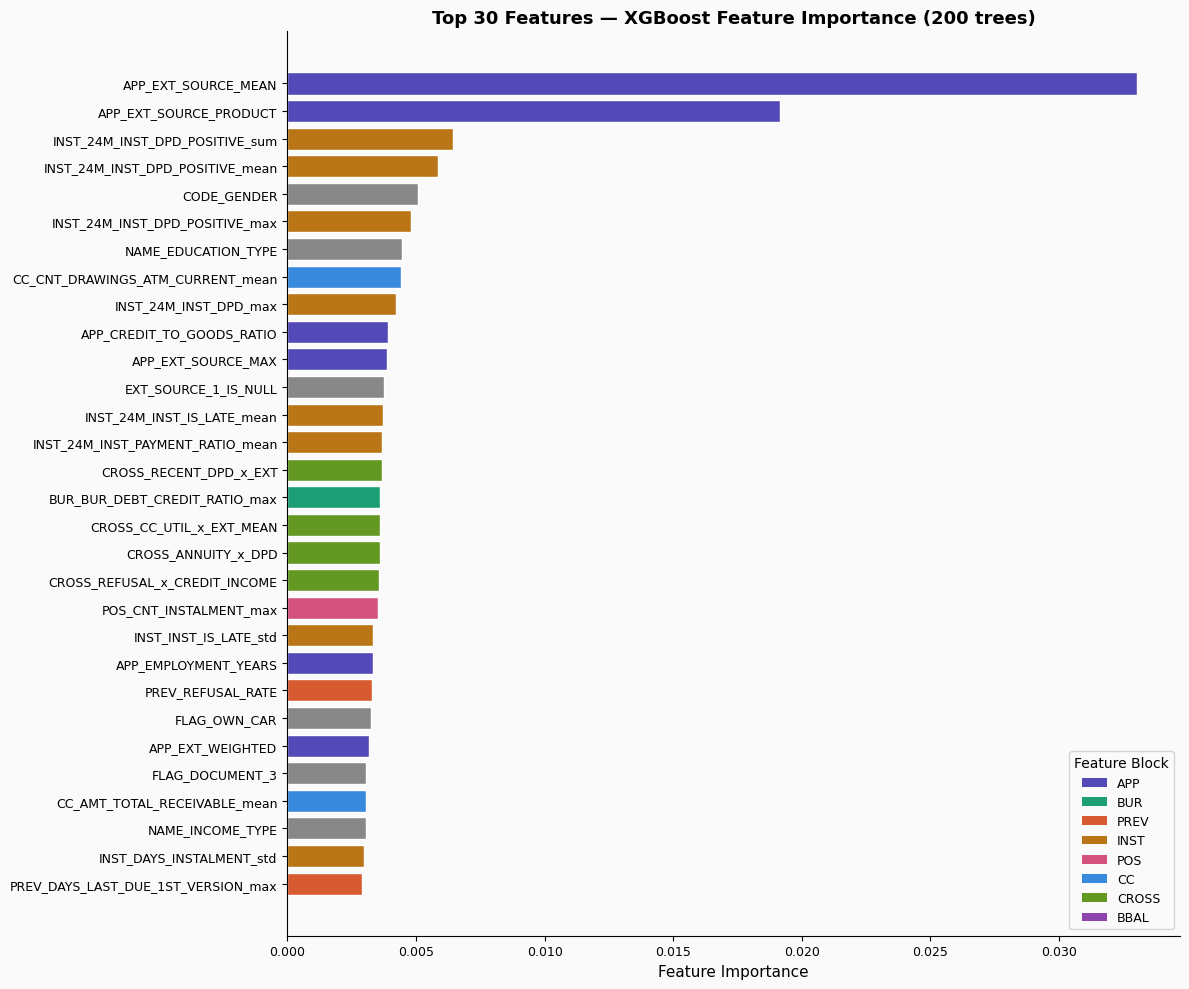

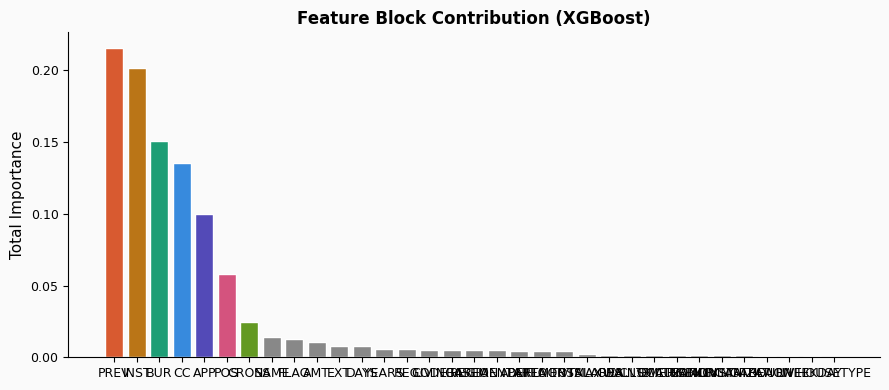


Bottom 10%% importance features (71) — candidates for PCA-only treatment
Saved: feature_importance_xgb.csv → Phase 5 will use this for PCA block selection


In [18]:
# ── Feature importance preview — XGBoost (your chosen model) ─────────────────
try:
    import xgboost as xgb
    from sklearn.model_selection import train_test_split

    FEAT_COLS = [c for c in master_train.columns if c not in ['SK_ID_CURR','TARGET']]
    X = master_train[FEAT_COLS].fillna(0).values
    y = master_train['TARGET'].values

    X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2,
                                                  stratify=y, random_state=42)
    scale_pos = (y == 0).sum() / (y == 1).sum()

    clf = xgb.XGBClassifier(
        n_estimators      = 200,
        learning_rate     = 0.05,
        max_depth         = 6,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        scale_pos_weight  = scale_pos,
        eval_metric       = 'auc',
        early_stopping_rounds = 20,
        random_state      = 42,
        n_jobs            = -1,
        verbosity         = 0,
        tree_method       = 'hist',   # fast histogram method
    )
    clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    val_auc = clf.best_score
    print(f'XGBoost quick run — best val AUC: {val_auc:.5f} at tree {clf.best_iteration}')

    imp_df = pd.DataFrame({
        'Feature'   : FEAT_COLS,
        'Importance': clf.feature_importances_,
        'Block'     : [c.split('_')[0] for c in FEAT_COLS],
    }).sort_values('Importance', ascending=False)

    print(f'\nTop 30 features by XGBoost importance:')
    display(imp_df.head(30))

    # Top 30 chart
    top30 = imp_df.head(30)
    block_colors = {
        'APP':'#534AB7','BUR':'#1D9E75','PREV':'#D85A30',
        'INST':'#BA7517','POS':'#D4537E','CC':'#378ADD',
        'CROSS':'#639922','BBAL':'#8E44AD',
    }
    colors = [block_colors.get(b, '#888888') for b in top30['Block']]

    fig, ax = plt.subplots(figsize=(12, 10))
    ax.barh(top30['Feature'], top30['Importance'], color=colors, edgecolor='white')
    ax.set_title('Top 30 Features — XGBoost Feature Importance (200 trees)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Feature Importance')
    ax.invert_yaxis()
    from matplotlib.patches import Patch
    legend_elems = [Patch(facecolor=v, label=k) for k,v in block_colors.items()]
    ax.legend(handles=legend_elems, title='Feature Block', fontsize=9, loc='lower right')
    plt.tight_layout()
    plt.savefig('phase4_feature_importance_xgb.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Block-level contribution
    block_imp = imp_df.groupby('Block')['Importance'].sum().sort_values(ascending=False)
    fig2, ax2 = plt.subplots(figsize=(9, 4))
    ax2.bar(block_imp.index, block_imp.values,
            color=[block_colors.get(b,'#888') for b in block_imp.index], edgecolor='white')
    ax2.set_title('Feature Block Contribution (XGBoost)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Total Importance')
    plt.tight_layout()
    plt.savefig('phase4_block_contribution_xgb.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Save importance for Phase 5 — drop bottom 10% features before PCA
    LOW_IMP_THRESHOLD = imp_df['Importance'].quantile(0.10)
    low_imp_cols = imp_df[imp_df['Importance'] <= LOW_IMP_THRESHOLD]['Feature'].tolist()
    print(f'\nBottom 10%% importance features ({len(low_imp_cols)}) — candidates for PCA-only treatment')
    imp_df.to_csv(os.path.join(OUTPUT_DIR, 'feature_importance_xgb.csv'), index=False)
    print('Saved: feature_importance_xgb.csv → Phase 5 will use this for PCA block selection')

except ImportError:
    print('XGBoost not installed. Run: pip install xgboost')
    print('Skipping importance preview — feature engineering is complete regardless.')


In [19]:
# ── Phase 5 preparation — save metadata for PCA ───────────────────────────────
# Phase 5 needs to know:
# 1. Which columns were log-transformed in Phase 3 (for correct standardisation)
# 2. Which feature blocks exist (for per-block PCA)
# 3. Feature importance ranking (to drop noise before PCA)

FEATURE_COLS = [c for c in master_train.columns if c not in ['SK_ID_CURR','TARGET']]

# Block membership for per-block PCA in Phase 5
block_map = {}
for col in FEATURE_COLS:
    for prefix in ['APP','BUR','PREV','INST','INST_12M','INST_24M','POS','CC','CROSS','BBAL']:
        if col.startswith(prefix + '_'):
            block_map[col] = prefix
            break
    else:
        block_map[col] = 'OTHER'

block_df = pd.DataFrame({'Feature': list(block_map.keys()), 'Block': list(block_map.values())})

# Load log-transformed cols from Phase 3 if saved (optional)
log_transform_path = './preprocessed/log_transformed_cols.txt'
if os.path.exists(log_transform_path):
    with open(log_transform_path) as f:
        log_cols_phase3 = [l.strip() for l in f.readlines()]
    print(f'Loaded {len(log_cols_phase3)} log-transformed cols from Phase 3')
else:
    log_cols_phase3 = []
    print('log_transformed_cols.txt not found — Phase 5 will standardise all features uniformly')

block_df['Was_Log_Transformed'] = block_df['Feature'].isin(log_cols_phase3)
block_df.to_csv(os.path.join(OUTPUT_DIR, 'feature_block_map.csv'), index=False)

print(f'\nFeature block distribution:')
print(block_df['Block'].value_counts().to_string())
print(f'\nSaved: feature_block_map.csv → Phase 5 input')
print(f'Total features ready for Phase 5: {len(FEATURE_COLS)}')


Loaded 20 log-transformed cols from Phase 3

Feature block distribution:
Block
PREV     184
INST     125
BUR      121
CC       119
OTHER     82
POS       41
APP       26
CROSS     10

Saved: feature_block_map.csv → Phase 5 input
Total features ready for Phase 5: 708


In [20]:
# ── Schema alignment ──────────────────────────────────────────────────────────
train_feat_cols = set(master_train.drop(columns=['SK_ID_CURR','TARGET']).columns)
test_feat_cols  = set(master_test.drop(columns=['SK_ID_CURR']).columns)

in_tr_not_te = train_feat_cols - test_feat_cols
in_te_not_tr = test_feat_cols  - train_feat_cols

if in_tr_not_te:
    print(f'In train not test ({len(in_tr_not_te)}): {list(in_tr_not_te)[:5]}...')
    for c in in_tr_not_te:
        master_test[c] = 0

if in_te_not_tr:
    print(f'In test not train ({len(in_te_not_tr)}): {list(in_te_not_tr)[:5]}...')
    master_test = master_test.drop(columns=list(in_te_not_tr), errors='ignore')

# Align column order
final_feat_cols  = [c for c in master_train.columns if c not in ['SK_ID_CURR','TARGET']]
master_test      = master_test[['SK_ID_CURR'] + [c for c in final_feat_cols if c in master_test.columns]]

print(f'Final TRAIN : {master_train.shape}')
print(f'Final TEST  : {master_test.shape}')
print(f'Schema aligned: {"YES" if master_train.shape[1]-1 == master_test.shape[1] else "NO — check above"}')

# ── Save ─────────────────────────────────────────────────────────────────────
master_train.to_csv(os.path.join(OUTPUT_DIR, 'master_train.csv'), index=False)
master_test.to_csv(os.path.join(OUTPUT_DIR,  'master_test.csv'),  index=False)

# Save feature list for Phase 5 & 6
feat_list = pd.DataFrame({'Feature': final_feat_cols,
                           'Block'  : [c.split('_')[0] for c in final_feat_cols]})
feat_list.to_csv(os.path.join(OUTPUT_DIR, 'feature_list.csv'), index=False)

print(f'\nSaved:')
print(f'  master_train.csv  → {master_train.shape}')
print(f'  master_test.csv   → {master_test.shape}')
print(f'  feature_list.csv  → {len(final_feat_cols)} features')
print(f'  Location: {os.path.abspath(OUTPUT_DIR)}')

Final TRAIN : (307511, 710)
Final TEST  : (48744, 709)
Schema aligned: YES

Saved:
  master_train.csv  → (307511, 710)
  master_test.csv   → (48744, 709)
  feature_list.csv  → 708 features
  Location: c:\Users\User\Desktop\project\new notebooks\features
